# Model comparison: inference precision and speed 

This notebook shows how to load the available models in the folder `model_hub/`, already pretrained using [this dataset](https://github.com/matteobonotto/ITERlike-equilibrium-dataset), and check their precision in terms of reconstructing the flux and the Grad-Shafranov operators.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from copy import deepcopy
from time import time
import torch
from pathlib import Path
from tqdm import tqdm
from typing import Dict, List
import pandas as pd
import pickle
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm


from planetequil import PlaNet
from planetequil.utils import read_h5_numpy, dummy_planet_input_np, dummy_planet_input_tensor, load_config
from planetequil.data import PlaNetDataset, Scaler
from planetequil.train import DataModule, collate_fun
from planetequil.config import Config
from planetequil.plot import contourf
from planetequil.constants import DTYPE
from planetequil.types import _TypeNpFloat

from torch.utils.data import DataLoader

In [3]:
def barplot_subplot(df: pd.DataFrame, ax:plt.Axes, title:str):
    means = df.mean()
    stds = df.std()
    num_cols = means.shape[0]

    cmap = cm.get_cmap('tab10' if num_cols <= 10 else 'tab20')
    colors = [cmap(i % cmap.N) for i in range(num_cols)]

    # Plot
    
    bars = ax.bar(df.columns, means, yerr=stds, capsize=5, color=colors)

    # Add legend (one entry per bar/column)
    ax.legend(bars, df.columns, title="Columns")

    # Add labels
    ax.set_ylabel('Mean Value')
    ax.set_title('Mean and Standard Deviation per Column')
    ax.set_title(title)

## Inference precision

Loading model from ../model_hub/planet


100%|██████████| 4/4 [00:00<00:00, 14.29it/s]


Loading model from ../model_hub/planet_slim


100%|██████████| 4/4 [00:00<00:00, 25.94it/s]


Loading model from ../model_hub/planet_slim_mlp


100%|██████████| 4/4 [00:00<00:00, 93.98it/s]


Loading model from ../model_hub/planet_no_physics_informed


100%|██████████| 4/4 [00:00<00:00, 71.73it/s]
/var/folders/1z/0p630gzs7zv8cgz4xtmr08pr0000gn/T/ipykernel_24034/2230888092.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10' if num_cols <= 10 else 'tab20')




 Mean error for the flux 
planet                        0.113839
planet_slim                   0.086746
planet_slim_mlp               0.176965
planet_no_physics_informed    0.340270
dtype: float64


 Mean error for the GS operator 
planet                        0.025811
planet_slim                   0.026493
planet_slim_mlp               0.034909
planet_no_physics_informed    0.313620
dtype: float64


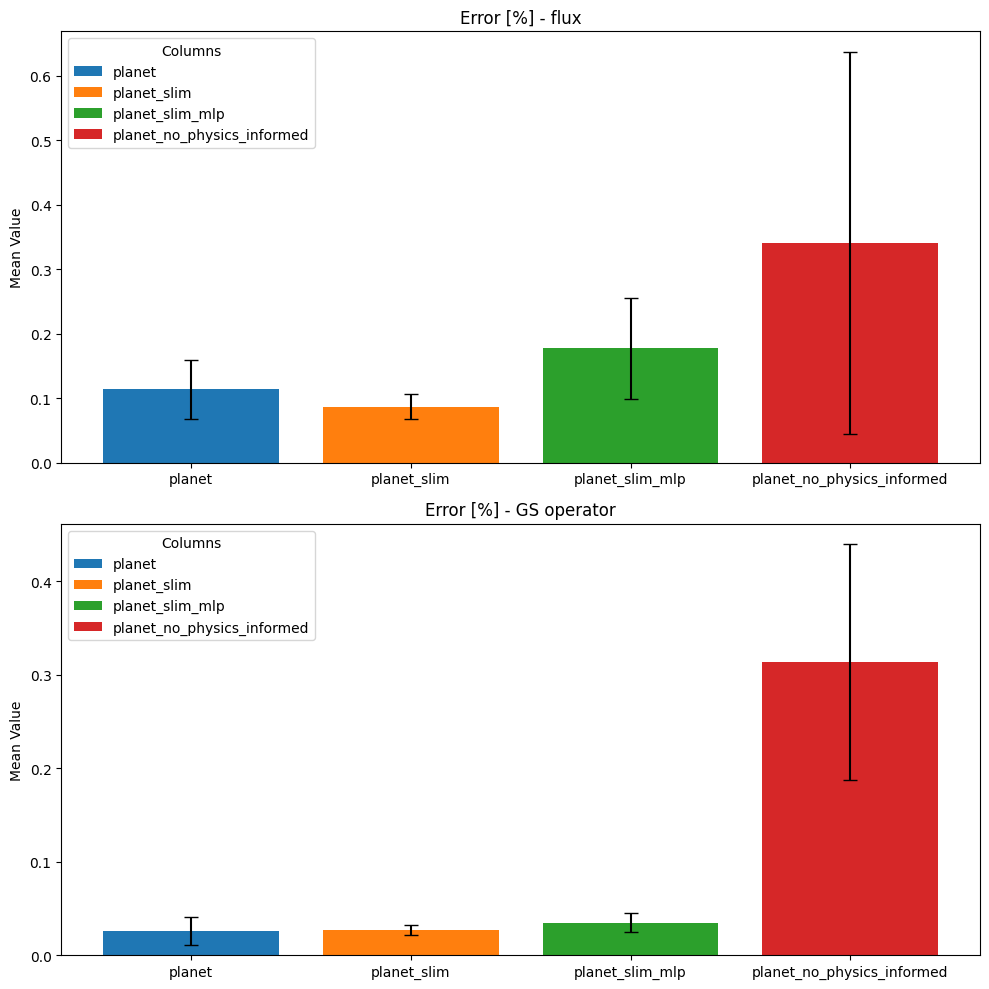

In [4]:
data = read_h5_numpy("planet_sample_dataset.h5")
# data = read_h5_numpy("../data/iter_like_data.h5")


loss_flux = {}
loss_gsope = {}
batch_size = 16
n_tot = data['measures'].shape[0]//batch_size
for model_path in Path("../model_hub").iterdir():
    if 'planet' not in model_path.name:
        continue
    model = PlaNet.from_pretrained(
        path=model_path
    )
    for i in tqdm(range(n_tot), total=n_tot):
        loss_flux[model_path.name] = []
        loss_gsope[model_path.name] = []

        idx = slice(i*batch_size, (i+1)*batch_size)

        #this step is required because the implace scaling will otherwise edit the 
        # data in the dataset
        inputs = {
                "measures" : deepcopy(data['measures'][idx, ...]),
                "rr" : data['RR_grid'],
                "zz" : data['ZZ_grid']
            }
        flux = model(**inputs)

        gs_ope = model.compute_gs_operator(
            flux=flux,
            rr=data['RR_grid'],
            zz=data['ZZ_grid'],
        )

        loss_flux[model_path.name].extend(
            np.mean(np.mean(flux-data['flux'][idx, ...], axis=1), axis=-1)
        )
        
        loss_gsope[model_path.name].extend(
            np.mean(np.mean(gs_ope-data['rhs'][idx,1:-1,1:-1], axis=1), axis=-1)
        )

loss_flux = {k:[abs(x) for x in v] for k,v in loss_flux.items()}
loss_gsope = {k:[abs(x) for x in v] for k,v in loss_gsope.items()}

scale_flux = np.abs(data['flux']).max()
scale_gsope = np.abs(data['rhs']).max()

print('\n')
percentage_error_flux_df = 100*pd.DataFrame(loss_flux)/scale_flux
print(" Mean error for the flux ")
print(percentage_error_flux_df.mean())

print('\n')

print(" Mean error for the GS operator ")
percentage_error_gsope_df = 100*pd.DataFrame(loss_gsope)/scale_gsope
print(percentage_error_gsope_df.mean())


fig, ax = plt.subplots(2,1, figsize=(10,10))
barplot_subplot(percentage_error_flux_df, ax=ax[0], title = "Error [%] - flux")
barplot_subplot(percentage_error_gsope_df, ax=ax[1], title = "Error [%] - GS operator")
plt.tight_layout()
plt.show()



## Inference speed
Compare the models and evaluate the inference speed on a single sample. 

Since we are evaluating a single sample (equal to `batch_size` of 1), and we are simulating the case in which the measures comes from the sensors and would need to be tranferred to the GPU, the whole inference pipeline is more likely to be faster on the CPU.

Loading model from ../model_hub/planet
Running model planet multiple times ...
Loading model from ../model_hub/planet_slim
Running model planet_slim multiple times ...
Loading model from ../model_hub/planet_slim_mlp
Running model planet_slim_mlp multiple times ...
Loading model from ../model_hub/planet_no_physics_informed
Running model planet_no_physics_informed multiple times ...
     planet  planet_slim  planet_slim_mlp  planet_no_physics_informed
0  3.449477     2.132584         0.889186                    3.131939


/var/folders/1z/0p630gzs7zv8cgz4xtmr08pr0000gn/T/ipykernel_24034/2230888092.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10' if num_cols <= 10 else 'tab20')


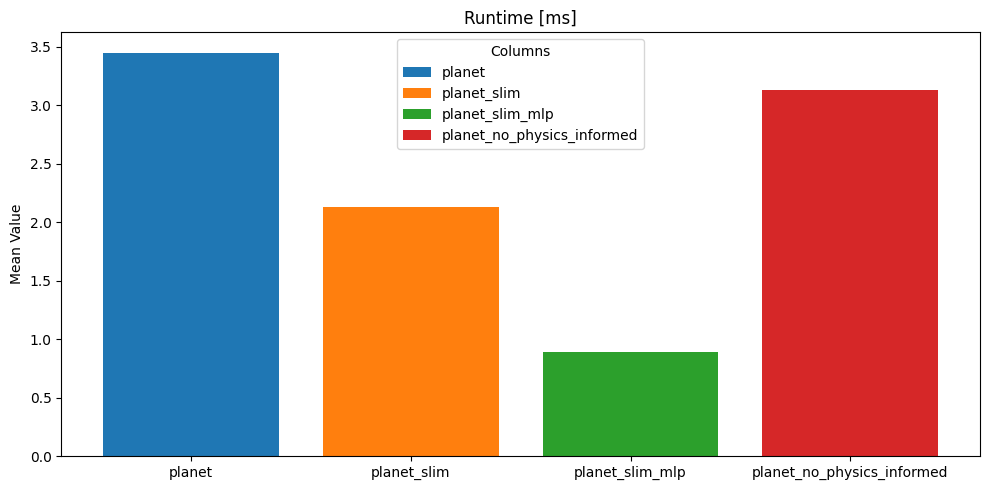

In [6]:

def eval_runtime(planet: PlaNet,  inputs: Dict[str, _TypeNpFloat], N_runs:int = 100) -> float:
    t_start = time()
    for _ in range(N_runs):
        _ = planet(**inputs)
    t_elapsed = (time() - t_start)/N_runs
    return t_elapsed

data = read_h5_numpy("planet_sample_dataset.h5")
idx_sample = 15
planet_inputs = {
    "measures":data['measures'][idx_sample, ...],
    "rr":data['RR_grid'],
    "zz":data['ZZ_grid'],
}

device = torch.device('cpu')
N_runs = 1000

t_run: Dict[str, float] = {}
for model_path in Path("../model_hub").iterdir():
    if 'planet' not in model_path.name:
        continue
    planet = PlaNet.from_pretrained(
        path=model_path
    )

    planet.model = planet.model.to(device)
    planet.device = device

    print(f"Running model {model_path.name} multiple times ...")
    t_run[model_path.name] = eval_runtime(planet, planet_inputs, N_runs)


runtime_df = pd.DataFrame({k:[1e3*v] for k,v in t_run.items()})
print(runtime_df)

fig, ax = plt.subplots(1,1, figsize=(10,5))
barplot_subplot(runtime_df, ax=ax, title = "Runtime [ms]")
plt.tight_layout()
plt.show()